Задача соревнования - предсказать вероятность того, что водитель примет заказ на основе набора параметров. На реакцию водителя влияет несколько факторов: расстояние до предложения, адрес назначения, время суток и т. д.

In [1]:
# Загрузка библиотек

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from geopy.distance import geodesic
import pylab
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score
import eli5
from eli5.sklearn import PermutationImportance
import shap

import warnings                                                   
warnings.filterwarnings('ignore') 

sns.set_theme(style="darkgrid")

In [2]:
SEED = 25

In [3]:
# Загрузка данных
taxi_df = pd.read_csv(r'C:\Users\Uckfo\test\taxi.xls', sep=',')

In [4]:
taxi_df.head(3)

,offer_gk,weekday_key,hour_key,driver_gk,order_gk,driver_latitude,driver_longitude,origin_order_latitude,origin_order_longitude,distance_km,duration_min,offer_class_group,ride_type_desc,driver_response
0,1105373,5,20,6080,174182,55.818842,37.334562,55.814567,37.355010,-1.000,-1.000,Economy,private,0
1,759733,5,14,6080,358774,55.805342,37.515023,55.819329,37.466398,18.802,25.217,Standard,private,1
2,416977,6,14,6080,866260,55.813978,37.347688,55.814827,37.354074,6.747,9.800,Economy,private,0


In [5]:
# Посмотрим, есть ли пропущенные значения
taxi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   offer_gk                100000 non-null  int64  
 1   weekday_key             100000 non-null  int64  
 2   hour_key                100000 non-null  int64  
 3   driver_gk               100000 non-null  int64  
 4   order_gk                100000 non-null  int64  
 5   driver_latitude         100000 non-null  float64
 6   driver_longitude        100000 non-null  float64
 7   origin_order_latitude   100000 non-null  float64
 8   origin_order_longitude  100000 non-null  float64
 9   distance_km             100000 non-null  float64
 10  duration_min            100000 non-null  float64
 11  offer_class_group       100000 non-null  object 
 12  ride_type_desc          100000 non-null  object 
 13  driver_response         100000 non-null  int64  
dtypes: float64(6), int64(

Произведем разбивку на train и test датасеты. C помощью train датасета будем обучать модель и проверять результаты на кросс-валидации, а с помощью test датасета будем проверять итоговое качество нашей модели.

In [6]:
# Выделим переменные
X = taxi_df.drop(['driver_response'], axis=1)
y = taxi_df['driver_response']

In [7]:
# Посмотрим на соотношение классов
y.value_counts(normalize=True)

0    0.50752
1    0.49248
Name: driver_response, dtype: float64

Классы хорошо сбалансированы, а это значит, что мы не ограничены в выборе метрики качества модели. В дальнейшем будем использовать метрику accuracy.

In [8]:
# Разбивка датасета на train и test, под тестовую выборку оставим 20% данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=SEED)

Убедимся, что после разбивки датасета на части, классы остались так же сбалансированы.

In [9]:
y_train.value_counts(normalize=True)

0    0.506575
1    0.493425
Name: driver_response, dtype: float64

In [10]:
y_test.value_counts(normalize=True)

0    0.5113
1    0.4887
Name: driver_response, dtype: float64

Будем производить весь анализ и поиск признаков в train, представляющий из себя тренировочную выборку X_train и y_train, чтобы обучать классификатор только на тренировочном датасете, не допуская лика данных.

In [11]:
train = taxi_df.loc[X_train.index]

In [12]:
train.head(3)

,offer_gk,weekday_key,hour_key,driver_gk,order_gk,driver_latitude,driver_longitude,origin_order_latitude,origin_order_longitude,distance_km,duration_min,offer_class_group,ride_type_desc,driver_response
28998,894855,6,18,1060,35186,55.961859,37.407126,55.962322,37.407117,40.446,39.350,Standard,private,0
54106,315637,3,8,1153,871383,55.719997,37.609617,55.726737,37.622140,-1.000,-1.000,Economy,business,1
73975,370099,4,23,462,107552,55.962083,37.417515,55.962322,37.407117,36.841,36.133,Economy,private,0


В столбцах distance_km и duration_min есть значения со значением '-1'. Возможно, что пользователь сделал заказ такси и не указал метку прибытия, вследствие этого появились такие значения признака.

In [13]:
# Проверим количество значений с отрицательными distance_km и duration_min
train.query('distance_km == -1').shape

(20887, 14)

In [14]:
# Посмотрим на соотношение таргета при отрицательных distance_km и duration_min
train.query('distance_km == -1')['driver_response'].value_counts(normalize=True)

1    0.551826
0    0.448174
Name: driver_response, dtype: float64

В таблице почти 21 тысяча строк с отрицательными значениями дистанции и длительности поездки, но при этом 55% подобных заказов были приняты таксистами. Возможно, метка '-1', которая говорит об отсутствии этих значений, может быть полезной для нашей модели и нести дополнительную информацию, и поэтому заменять эти значения нулями или средними значениями из других строк может негативно повлиять на ее качество.

Так же обнаружились и другие пропущенные значения в столбцах координат водителя и заказчика такси, найти их не составит труда.

In [15]:
train.query('driver_latitude == driver_longitude.min()').head(3)

,offer_gk,weekday_key,hour_key,driver_gk,order_gk,driver_latitude,driver_longitude,origin_order_latitude,origin_order_longitude,distance_km,duration_min,offer_class_group,ride_type_desc,driver_response
22629,31647,4,15,2183,523673,-1.0,-1.0,55.593641,37.242432,-1.0,-1.0,Standard,business,1
33915,22610,2,23,2848,22032,-1.0,-1.0,55.694926,37.380291,-1.0,-1.0,Standard,business,1
54363,461772,4,10,6166,379629,-1.0,-1.0,55.415361,37.898917,-1.0,-1.0,Standard,business,1


In [16]:
train.query('origin_order_latitude == origin_order_longitude.min()').head(3)

,offer_gk,weekday_key,hour_key,driver_gk,order_gk,driver_latitude,driver_longitude,origin_order_latitude,origin_order_longitude,distance_km,duration_min,offer_class_group,ride_type_desc,driver_response
56004,1009826,3,19,4185,247078,55.758792,37.749308,-1.0,-1.0,11.281,21.167,Economy,private,1
67170,638165,5,16,4567,354669,55.770791,37.511972,-1.0,-1.0,13.997,27.717,Standard,private,1
51365,833482,0,20,75,782429,55.619920,37.395172,-1.0,-1.0,28.607,32.967,Economy,private,0


Взглянем на распределения широты и долготы водителей и заказчиков, чтобы понять, каков радиус всей области.

In [17]:
def coordinates_hist():
    
    plt.figure(figsize=(14,8))
    coordinates = ['driver_latitude', 'driver_longitude', 'origin_order_latitude', 'origin_order_longitude']
    title = ['Histogram driver_latitude', 'Histogram driver_longitude', 
             'Histogram origin_order_latitude', 'Histogram origin_order_longitude']
    
    for i in range(4):
        pylab.subplot(2, 2, i+1)
        X_train[X_train[coordinates[i]] > 0][coordinates[i]].hist();
        plt.title(title[i]);

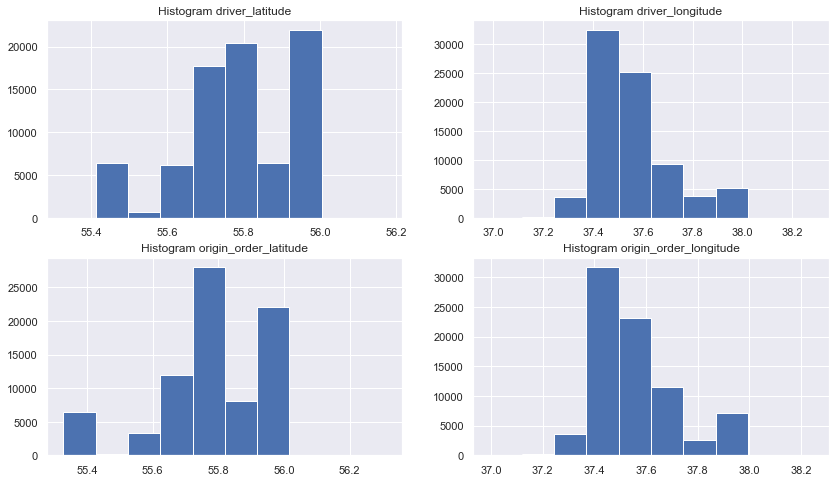

In [18]:
coordinates_hist()

Если посмотреть по координатам, то можно понять, что действия происходят в Москве и МО с примерным диаметром ~100 км.

In [19]:
# Измерения расстояний между двумя точками производим с помощью библиотеки geopy
geodesic((55.327636, 37.497954), (56.174097, 37.509228)).kilometers

94.24532817771619

Таких значений насчитывается чуть больше 150, что в пределах погрешности, поэтому заполним их средним значением координат широты и долготы.

In [20]:
def mean_coordinates(df):
    
    # Сохраним средние значения широты и долготы водителей и пользователей в отдельные переменные
    mean_driver_latitude = df[df['driver_latitude'] > 0]['driver_latitude'].mean()
    mean_driver_longitude = df[df['driver_longitude'] > 0]['driver_longitude'].mean()
    mean_origin_order_latitude = df[df['origin_order_latitude'] > 0]['origin_order_latitude'].mean()
    mean_origin_order_longitude = df[df['origin_order_longitude'] > 0]['origin_order_longitude'].mean()

    # Заменим отрицательные значения найденными средними значениями
    df['driver_latitude'] = df['driver_latitude'].apply(lambda x: (mean_driver_latitude if x in [-1, 0] else x))
    df['driver_longitude'] = df['driver_longitude'].apply(lambda x: (mean_driver_longitude if x in [-1, 0] else x))
    df['origin_order_latitude'] = df['origin_order_latitude'].apply(lambda x: (mean_origin_order_latitude if x in [-1, 0] else x))
    df['origin_order_longitude'] = df['origin_order_longitude'].apply(lambda x: (mean_origin_order_longitude if x in [-1, 0] else x))
    return df

In [21]:
X_train = mean_coordinates(X_train)

В качестве Baseline используем константный предсказатель, который будет предсказывать самый частый класс.

In [22]:
train['driver_response'].value_counts(normalize=True)

0    0.506575
1    0.493425
Name: driver_response, dtype: float64

Самый частый класс - 0. Рассчитаем точность на тестовых данных.

In [23]:
y_pred = [0] * X_test.shape[0]
print('Baseline: {:.3f}'.format(accuracy_score(y_pred, y_test)))

Baseline: 0.511


### Feature extraction

Добавим новый признак - расстояние от водителя до заказчика такси в момент получения заказа. Определять его будем при помощи координат и библиотеки geopy.

In [24]:
def create_destination_feature(df):
    
    coordinates = ['driver_latitude', 'driver_longitude', 'origin_order_latitude', 'origin_order_longitude']
    
    destinations = list()
    for i in range(0, df.shape[0]):
        destinations.append(geodesic((df[coordinates[0]].iloc[i], df[coordinates[1]].iloc[i]), 
                                     (df[coordinates[2]].iloc[i], df[coordinates[3]].iloc[i])).kilometers)
    df['destination'] = pd.Series(destinations, index=df.index)
    return df

In [25]:
X_train = create_destination_feature(X_train)

С помощью признака destination можем сразу добавить новый признак - отношение расстояния от водителя до заказчика и расстояния планируемой поездки.
Если расстояние от водителя до заказчика больше, чем расстояние планируемой поездки, то для таксиста это предложение
может быть невыгодным и он, вероятно, может отказаться от него. Добавим этот признак и визуализируем, так ли это на самом деле.

In [26]:
def create_dest_ratio_feature(df):
    
    def dest_ratio(row):
        dest = row[0]
        dist = row[1]
        dist = 0.001 if dist == 0 else dist
        result = dest / dist
        result = -1 if dist == -1 else result
        return result
    
    df['destination_ratio'] = df[['destination', 'distance_km']].apply(dest_ratio, axis=1)
    return df

In [27]:
X_train = create_dest_ratio_feature(X_train)

Данные показывают следующее: 45% процентов заказов таксисты отклоняют, если расстояние до заказчика больше расстояния планируемой поездки. 
    Таких случаев меньше 1000, но при этом нам неизвестно, какая ситуация сложилась с заказами, где расстояние поездки неизвестно (т.е. там, где стоит метка '-1').

In [28]:
y_train.loc[X_train[X_train['distance_km'] >= 0].query('destination > distance_km').index].value_counts()

1    510
0    421
Name: driver_response, dtype: int64

Проанализируем заказы такси по дням недели и по часам. 

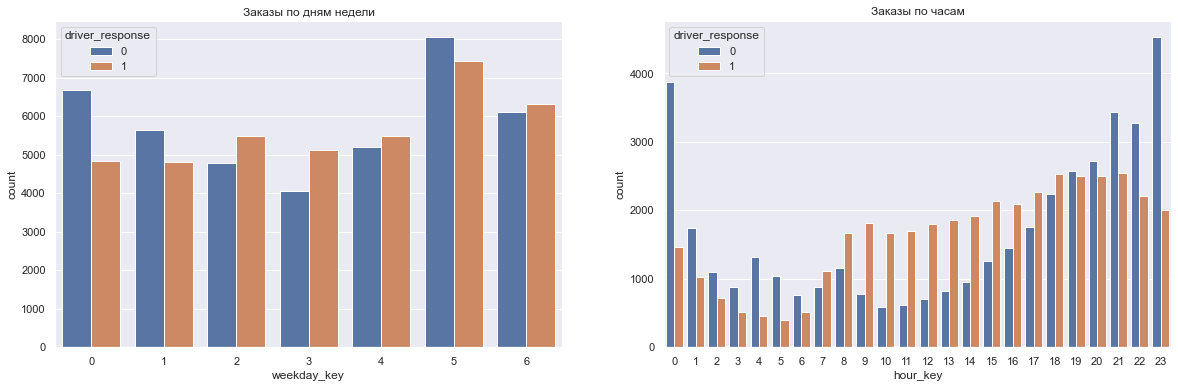

In [29]:
plt.figure(figsize=(20,6))

pylab.subplot(1, 2, 1)
sns.countplot(x='weekday_key', hue='driver_response', data=train);
plt.title('Заказы по дням недели');

pylab.subplot(1, 2, 2)
sns.countplot(x='hour_key', hue='driver_response', data=train);
plt.title('Заказы по часам');

Из графика по дням видно, что наибольшее количество заказов приходится на 5 день. 
А если посмотреть на график по часам, то видно, что с 8 утра и до вечера заказы чаще принимают, 
а начиная с 19 часов и вплоть до утра заказы чаще отклоняют. А что, если построить графики по часам на каждый день недели? Попробуем это сделать.

In [30]:
def weekday_hour_plot():
    
    plt.figure(figsize=(17,22))
    for i in range(7):
        pylab.subplot(4, 2, i+1)
        sns.countplot(x=train[train['weekday_key'] == i]['hour_key'], hue='driver_response', data=train);
        plt.title('Заказы по часам в {} день'.format(i));

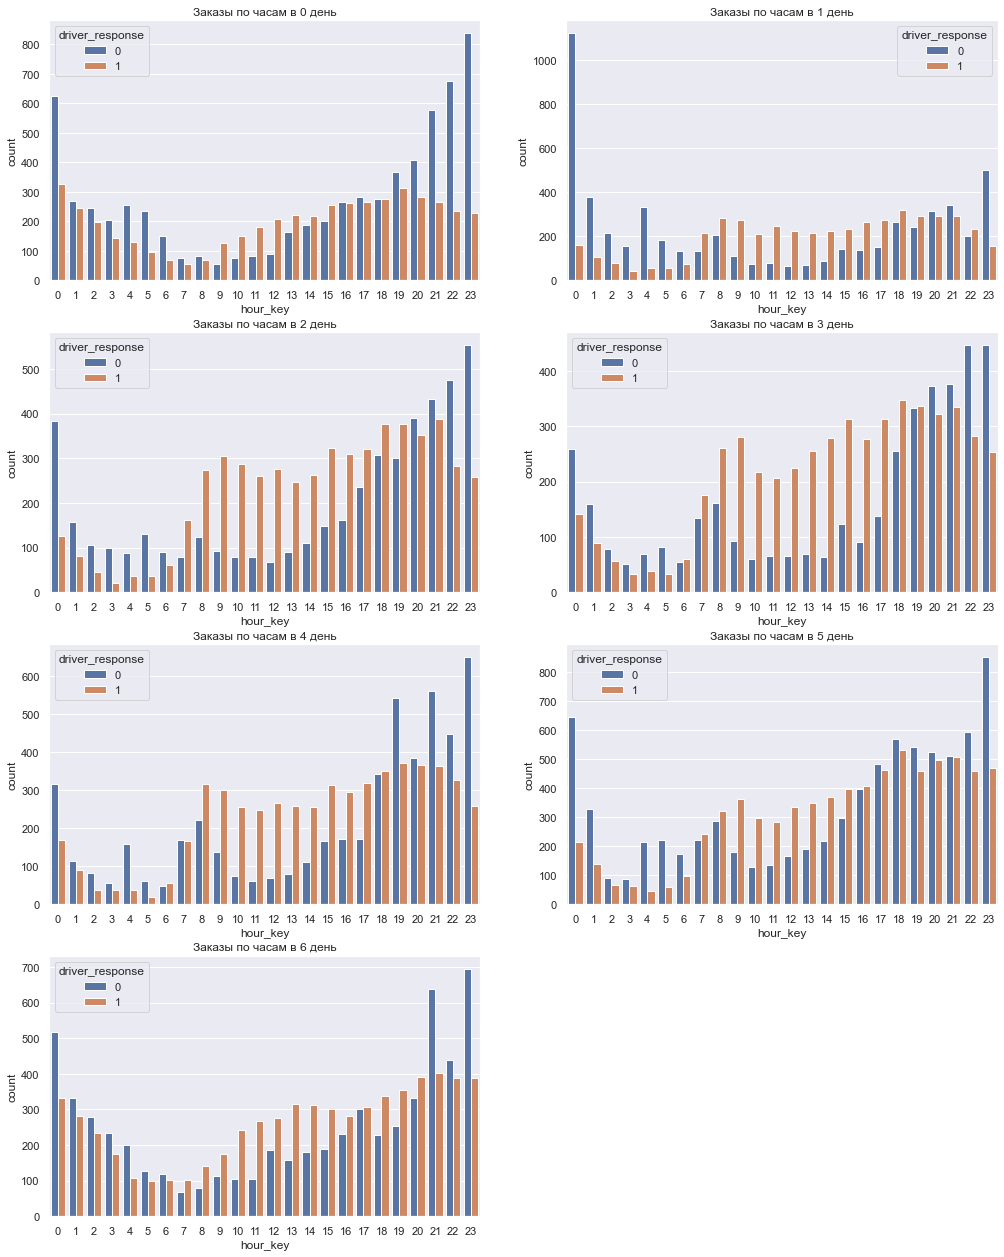

In [31]:
weekday_hour_plot()

На основании этих графиков создадим новый признак, который будет учитывать ситуацию с заказами на каждый день и час. 
Представлять из себя он будет отношение принятых заказов к отклоненным на определенный день и час.

In [32]:
def create_weekday_hour_ratio_feature(df):
    
    df_index = df.index
    ratio_list = list()
    response_count_list = train.groupby(by=['weekday_key', 'hour_key', 'driver_response']) \
                               .count().reset_index().iloc[:, 3].tolist()
    
    for i in range(1, len(response_count_list), 2):
        ratio_list.append(response_count_list[i] / response_count_list[i-1])
    
    weekday_hour_ratio = pd.Series(ratio_list, index=train.groupby(by=['weekday_key', 'hour_key']) \
                                .count().index).reset_index().rename({0: 'weekday_hour_ratio'}, axis=1)
    
    df = df.merge(weekday_hour_ratio, how='left', on=['weekday_key', 'hour_key']).set_index(df_index)
    return df

In [33]:
X_train = create_weekday_hour_ratio_feature(X_train)

Посмотрим на статистику заказов двух произвольно взятых из выборки таксистов.

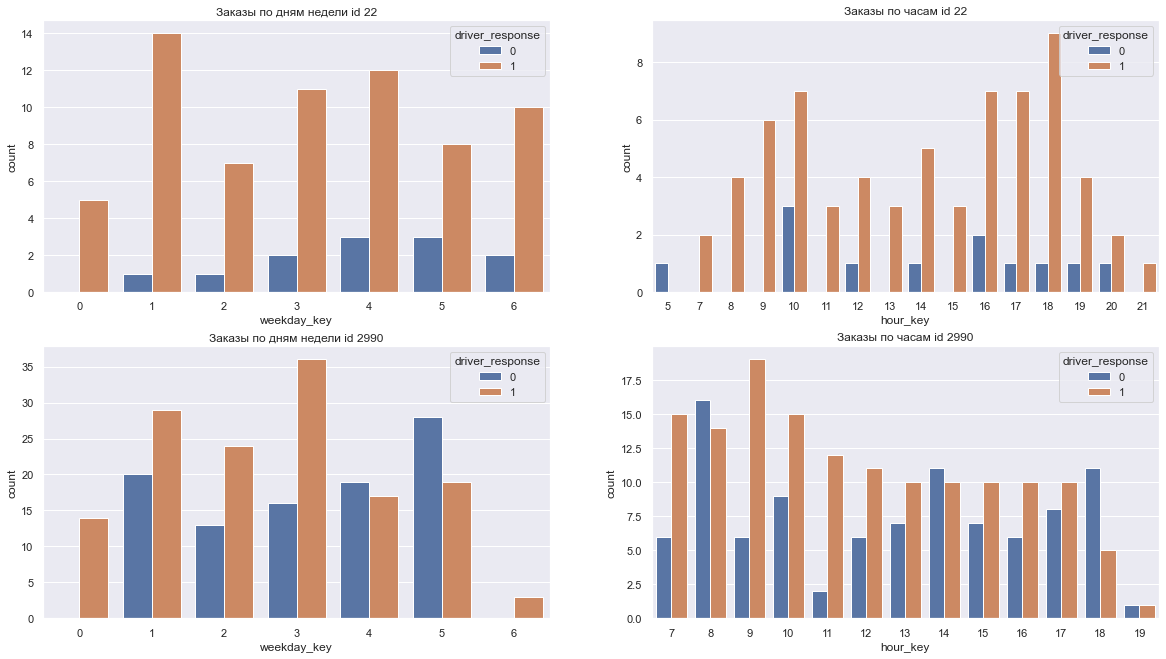

In [34]:
plt.figure(figsize=(20,11))

pylab.subplot(2, 2, 1)
sns.countplot(x=train['weekday_key'].loc[train['driver_gk'][train['driver_gk'] == 22].index], hue=train['driver_response'].loc[train['driver_gk'][train['driver_gk'] == 22].index], data=train);
plt.title('Заказы по дням недели id 22');

pylab.subplot(2, 2, 2)
sns.countplot(x=train['hour_key'].loc[train['driver_gk'][train['driver_gk'] == 22].index], hue=train['driver_response'].loc[train['driver_gk'][train['driver_gk'] == 22].index], data=train);
plt.title('Заказы по часам id 22');

pylab.subplot(2, 2, 3)
sns.countplot(x=train['weekday_key'].loc[train['driver_gk'][train['driver_gk'] == 2990].index], hue=train['driver_response'].loc[train['driver_gk'][train['driver_gk'] == 2990].index], data=train);
plt.title('Заказы по дням недели id 2990');

pylab.subplot(2, 2, 4)
sns.countplot(x=train['hour_key'].loc[train['driver_gk'][train['driver_gk'] == 2990].index], hue=train['driver_response'].loc[train['driver_gk'][train['driver_gk'] == 2990].index], data=train);
plt.title('Заказы по часам id 2990');

In [35]:
# Возможные типы поездки
train['offer_class_group'].unique()

array(['Standard', 'Economy', 'Premium', 'Delivery', 'Kids', 'VIP', 'XL',
       'VIP+', 'Test'], dtype=object)

In [36]:
# Типы поездок у водителей
pd.DataFrame(train.groupby('driver_gk')['offer_class_group'].unique()).head(3)

,offer_class_group
driver_gk,
14,[Standard]
22,"[Standard, Economy, Kids]"
42,"[Economy, Standard]"


In [37]:
# Типы заказов у водителей
pd.DataFrame(train.groupby('driver_gk')['ride_type_desc'].unique()).head(3)

,ride_type_desc
driver_gk,
14,"[private, business]"
22,"[private, business]"
42,"[private, business]"


Из графиков следует, что у каждого таксиста свой индивидуальный график рабочего дня. Также каждый водитель принимает заказы определенного класса и на основании этого можно создать сразу 4 признака - признаки, учитывающие заказы таксистов по дням, по часам, по классу и типу поездки.

Рассчитываться они будут как driver_response_1 / (driver_response_1 + driver_response_0)



In [38]:
def create_ratio_features(df):
    '''
        Функция группирует значения по id водителя и создаваемому признаку, затем рассчитывает отношение классов 
    driver_response и заносит результат в таблицу в процентном соотношении, которая затем прикрепляется к датафрейму.
    
        Например, если таксист отклонил все заказы, результат будет 0, если принял половину всех заказов, то 0.5. 
    Во избежании появления NaN значений в тестовом датафрейме, где рабочее время таксистов может отличаться от времени
    в обучающей выборке, таким наблюдениям присваивается значение 0.5, как равновероятное принятию или отклонению заказа.
    
    '''
    
    features = ['weekday_key', 'hour_key', 'offer_class_group', 'ride_type_desc']
    name_features = ['driver_weekday_ratio', 'driver_hour_ratio', 'driver_class_ratio', 'driver_type_ratio']
    df_index = df.index
    
    for f in range(len(features)):
        
        ratio_list = list()
        response_count = train.groupby(['driver_gk', features[f], 'driver_response']).count()
        
        # уникальные id водителей
        drivers = train.groupby(['driver_gk']).count().reset_index()['driver_gk'].unique()
        
        # дни/часы/классы/типы конкретного водителя в зависимости от создаваемого признака
        feature_drivers = train.groupby(['driver_gk', features[f]]).count()
        
        for i in drivers:
            
            for j in feature_drivers['offer_gk'][i].index:
                
                if response_count['offer_gk'][i][j].size == 2:
                    ratio_list.append(response_count['offer_gk'][i][j][1] / 
                            (response_count['offer_gk'][i][j][1] + response_count['offer_gk'][i][j][0]))
                else:
                    if response_count['offer_gk'][i][j].index == 1:
                        ratio_list.append(1)
                    else:
                        ratio_list.append(0)
                        
    feature_ratio = pd.Series(ratio_list, index=train.groupby(['driver_gk', features[f]]).count().index) \
                                .reset_index().rename({0: name_features[f]}, axis=1)
        
    df = df.merge(feature_ratio, how='left', on=['driver_gk', features[f]]).set_index(df_index).fillna(0.5)
    
    return df

In [39]:
X_train = create_ratio_features(X_train)

Зная расстояние и длительность планируемой поездки, добавим новый признак - скорость движения. Для значений с меткой -1 в значении признака укажем так же -1.

In [40]:
def create_speed_feature(df):
    df['speed_km'] = (df['distance_km'].apply(lambda x: 0.0001 if x == 0 else x) /
                     ((df['duration_min'].apply(lambda x: 0.0001 if x == 0 else x) * 60) / 3600)) \
                        .apply(lambda x: -1 if x == 60 else x)
    
    return df

In [41]:
X_train = create_speed_feature(X_train)

### Feature transformation

Преобразуем категориальные признаки offer_class_group и ride_type_desc при помощи One Hot Encoding.

In [42]:
def get_dummies(df):
    df = df.merge(pd.get_dummies(df['offer_class_group'], prefix='offer_class'), how='inner', on=df.index) \
                 .rename({'key_0': 'id'}, axis=1) \
                 .set_index('id') \
                 .drop(['offer_class_group'], axis=1)
    
    df = df.merge(pd.get_dummies(df['ride_type_desc'], prefix='ride_type'), how='inner', on='id') \
                 .drop(['ride_type_desc'], axis=1)
    return df

In [43]:
X_train_no_ohe = X_train.copy()
X_train = get_dummies(X_train)

Отмасштабируем все признаки при помощи StandardScaler.

In [44]:
def scale_features(X, features):
    X_scaled = X.copy()
    for feature in features:
        scaler = StandardScaler()
        scaler.fit(X_scaled[feature].values.reshape(-1, 1))
        X_scaled[feature + '_scaled'] = scaler.transform(X_scaled[feature].values.reshape(-1, 1))
        
    X_scaled = X_scaled.drop(features, axis=1)
    return X_scaled

In [45]:
X_train_scaled = scale_features(X_train, X_train.columns)

### Feature selection

Обучим логистическую регрессию, используя кросс-валидацию, в качестве метрики качества будем использовать accuracy.

In [46]:
def get_cv_score(X, y):
    
    skf = StratifiedKFold(n_splits=5, random_state=SEED, shuffle=True)
    logit = LogisticRegression(n_jobs=-1, random_state=SEED)
    scores = cross_val_score(logit, X, y, cv=skf, scoring='accuracy')
    
    print('mean_score in train: {:.4f}'.format(scores.mean()))

In [47]:
get_cv_score(X_train_scaled, y_train)

mean_score in train: 0.8298


Применим модель Catboost.

In [48]:
def cb_model_fit(X, y):
    catboost = CatBoostClassifier(eval_metric='Accuracy', random_state=SEED)
    
    train_cat, test_cat, y_train_cat, y_test_cat = train_test_split(
                                                X, y, 
                                                test_size=0.2, shuffle=True, 
                                                random_state=SEED
                                                )
    
    catboost.fit(train_cat, y_train_cat, eval_set=(test_cat, y_test_cat), verbose=50)
    
    y_pred = catboost.predict(test_cat)
    print('accuracy score: {:.3f}'.format(accuracy_score(y_test_cat, y_pred)))

In [49]:
cb_model_fit(X_train_scaled, y_train)

Learning rate set to 0.088519
0:	learn: 0.8195469	test: 0.8222500	best: 0.8222500 (0)	total: 167ms	remaining: 2m 46s
50:	learn: 0.8343281	test: 0.8354375	best: 0.8355625 (47)	total: 1.3s	remaining: 24.2s
100:	learn: 0.8393906	test: 0.8370625	best: 0.8374375 (87)	total: 2.47s	remaining: 22s
150:	learn: 0.8433906	test: 0.8371875	best: 0.8374375 (87)	total: 3.6s	remaining: 20.3s
200:	learn: 0.8480781	test: 0.8398125	best: 0.8401875 (193)	total: 4.76s	remaining: 18.9s
250:	learn: 0.8522344	test: 0.8401250	best: 0.8402500 (245)	total: 5.9s	remaining: 17.6s
300:	learn: 0.8558438	test: 0.8414375	best: 0.8418750 (297)	total: 7.05s	remaining: 16.4s
350:	learn: 0.8593281	test: 0.8420000	best: 0.8423125 (340)	total: 8.2s	remaining: 15.2s
400:	learn: 0.8620313	test: 0.8423125	best: 0.8425000 (354)	total: 9.36s	remaining: 14s
450:	learn: 0.8646406	test: 0.8423125	best: 0.8427500 (408)	total: 10.5s	remaining: 12.8s
500:	learn: 0.8672969	test: 0.8421250	best: 0.8427500 (408)	total: 11.5s	remaining: 1

Catboost в данной ситуации справился лучше, чем логистическая регрессия, поэтому дальше будем использовать catboost.

Известно, что для Catboost вовсе необязательно масштабировать признаки и применять One Hot Encoding, он хорошо справляется и без этого. Попробуем сравнить две модели между собой.

In [50]:
catboost = CatBoostClassifier(eval_metric='Accuracy', random_state=SEED)

train_cat, test_cat, y_train_cat, y_test_cat = train_test_split(
                                                X_train_no_ohe, y_train, 
                                                test_size=0.2, shuffle=True, 
                                                random_state=SEED
                                                )

pool_train = Pool(train_cat, y_train_cat, cat_features = ['offer_class_group', 'ride_type_desc'])
pool_test = Pool(test_cat, y_test_cat, cat_features = ['offer_class_group', 'ride_type_desc'])

catboost.fit(pool_train, verbose=50)

Learning rate set to 0.060838
0:	learn: 0.8196406	total: 107ms	remaining: 1m 47s
50:	learn: 0.8321406	total: 4.61s	remaining: 1m 25s
100:	learn: 0.8358281	total: 9.04s	remaining: 1m 20s
150:	learn: 0.8393125	total: 13.4s	remaining: 1m 15s
200:	learn: 0.8417031	total: 17.8s	remaining: 1m 10s
250:	learn: 0.8441406	total: 22.1s	remaining: 1m 5s
300:	learn: 0.8468594	total: 26.6s	remaining: 1m 1s
350:	learn: 0.8498594	total: 31s	remaining: 57.3s
400:	learn: 0.8518750	total: 35.4s	remaining: 52.8s
450:	learn: 0.8540313	total: 39.8s	remaining: 48.4s
500:	learn: 0.8560625	total: 44.3s	remaining: 44.2s
550:	learn: 0.8577656	total: 48.9s	remaining: 39.8s
600:	learn: 0.8594219	total: 53.3s	remaining: 35.4s
650:	learn: 0.8611562	total: 57.8s	remaining: 31s
700:	learn: 0.8625312	total: 1m 2s	remaining: 26.6s
750:	learn: 0.8648125	total: 1m 6s	remaining: 22.1s
800:	learn: 0.8663750	total: 1m 11s	remaining: 17.7s
850:	learn: 0.8685000	total: 1m 15s	remaining: 13.2s
900:	learn: 0.8698594	total: 1m 20

In [51]:
y_pred = catboost.predict(pool_test)
accuracy_score(y_pred, y_test_cat)

0.8426875

В данном случае вторая модель с неподготовленными данными справилась чуть хуже первой, но стоит отметить, 
что она обучалась в 5 раз дольше модели с подготовленными данными. В данном датасете это разница в 40 секунд, но если
будут данные с миллионами строк, разница будет куда более ощутимой.

Далее будем использовать модель с подготовленными данными.

Проведем оценку важности признаков и отбросим лишние признаки.

In [52]:
catboost = CatBoostClassifier(eval_metric='Accuracy', random_state=SEED)

train_cat, test_cat, y_train_cat, y_test_cat = train_test_split(
                                                X_train_scaled, y_train, 
                                                test_size=0.2, shuffle=True, 
                                                random_state=SEED
                                                )

catboost.fit(train_cat, y_train_cat, eval_set=(test_cat, y_test_cat), verbose=50)

perm = PermutationImportance(catboost).fit(test_cat, y_test_cat)
eli5.show_weights(perm)

Learning rate set to 0.088519
0:	learn: 0.8195469	test: 0.8222500	best: 0.8222500 (0)	total: 28ms	remaining: 28s
50:	learn: 0.8343281	test: 0.8354375	best: 0.8355625 (47)	total: 1.36s	remaining: 25.4s
100:	learn: 0.8393906	test: 0.8370625	best: 0.8374375 (87)	total: 2.67s	remaining: 23.7s
150:	learn: 0.8433906	test: 0.8371875	best: 0.8374375 (87)	total: 3.93s	remaining: 22.1s
200:	learn: 0.8480781	test: 0.8398125	best: 0.8401875 (193)	total: 5.07s	remaining: 20.2s
250:	learn: 0.8522344	test: 0.8401250	best: 0.8402500 (245)	total: 6.27s	remaining: 18.7s
300:	learn: 0.8558438	test: 0.8414375	best: 0.8418750 (297)	total: 7.46s	remaining: 17.3s
350:	learn: 0.8593281	test: 0.8420000	best: 0.8423125 (340)	total: 8.69s	remaining: 16.1s
400:	learn: 0.8620313	test: 0.8423125	best: 0.8425000 (354)	total: 9.89s	remaining: 14.8s
450:	learn: 0.8646406	test: 0.8423125	best: 0.8427500 (408)	total: 11s	remaining: 13.4s
500:	learn: 0.8672969	test: 0.8421250	best: 0.8427500 (408)	total: 12.1s	remaining:

Weight,Feature
0.2970 ± 0.0111,x14
0.0154 ± 0.0018,x5
0.0121 ± 0.0015,x7
0.0072 ± 0.0017,x13
0.0068 ± 0.0010,x11
0.0052 ± 0.0009,x8
0.0044 ± 0.0018,x17
0.0043 ± 0.0014,x6
0.0043 ± 0.0023,x15
0.0041 ± 0.0020,x9


In [53]:
importance = pd.DataFrame({'feature': train_cat.columns, 'importance': perm.feature_importances_}) \
                .sort_values('importance', ascending=False)

In [54]:
importance

,feature,importance
14,driver_type_ratio_scaled,0.297000
5,driver_latitude_scaled,0.015425
7,origin_order_latitude_scaled,0.012050
13,weekday_hour_ratio_scaled,0.007175
11,destination_scaled,0.006825
8,origin_order_longitude_scaled,0.005200
17,offer_class_Economy_scaled,0.004438
6,driver_longitude_scaled,0.004288
15,speed_km_scaled,0.004250
9,distance_km_scaled,0.004075


In [55]:
# Будем убирать признаки, имеющие importance < 0
X_train_scaled_importance = X_train_scaled.drop(importance.query('importance < 0')['feature'].tolist(), axis=1)

In [56]:
cb_model_fit(X_train_scaled_importance, y_train)

Learning rate set to 0.088519
0:	learn: 0.8210469	test: 0.8220625	best: 0.8220625 (0)	total: 20.4ms	remaining: 20.4s
50:	learn: 0.8341094	test: 0.8348125	best: 0.8350625 (42)	total: 1.09s	remaining: 20.2s
100:	learn: 0.8390000	test: 0.8373125	best: 0.8373125 (100)	total: 2.26s	remaining: 20.1s
150:	learn: 0.8437031	test: 0.8387500	best: 0.8387500 (150)	total: 3.43s	remaining: 19.3s
200:	learn: 0.8481406	test: 0.8387500	best: 0.8391250 (170)	total: 4.61s	remaining: 18.3s
250:	learn: 0.8523594	test: 0.8390625	best: 0.8394375 (221)	total: 5.76s	remaining: 17.2s
300:	learn: 0.8556563	test: 0.8397500	best: 0.8399375 (294)	total: 6.91s	remaining: 16s
350:	learn: 0.8592031	test: 0.8398125	best: 0.8403125 (324)	total: 8.06s	remaining: 14.9s
400:	learn: 0.8617969	test: 0.8410625	best: 0.8411250 (391)	total: 9.22s	remaining: 13.8s
450:	learn: 0.8642500	test: 0.8403750	best: 0.8413125 (429)	total: 10.4s	remaining: 12.6s
500:	learn: 0.8670000	test: 0.8418750	best: 0.8421250 (494)	total: 11.4s	rema

### Hyperparameter tuning

Найдем оптимальные гиперпараметры модели с помощью Optuna.

In [57]:
def optimize_hp(trial):
    cb_params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1, 100),
        'bagging_temperature': trial.suggest_loguniform('bagging_temperature', 0.1, 20.0),
        'random_strength': trial.suggest_float('random_strength', 1.0, 3.0),
        'depth': trial.suggest_int('depth', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 500),
        "use_best_model": True,
        'random_seed': SEED
    }
    
    model = CatBoostClassifier(**cb_params)
    model.fit(train_cat, y_train_cat, eval_set=(test_cat, y_test_cat), verbose=False)
    y_pred = model.predict(test_cat)
    return accuracy_score(y_test_cat, y_pred)

In [58]:
train_cat, test_cat, y_train_cat, y_test_cat = train_test_split(
                                                X_train_scaled_importance, y_train, 
                                                test_size=0.2, shuffle=True, 
                                                random_state=SEED
                                                )

study = optuna.create_study(direction="maximize")
study.optimize(optimize_hp, n_trials=50)
print('Trials:', len(study.trials))
print('Best parameters:', study.best_trial.params)
print('Best score:', study.best_value)

[I 2022-01-12 20:55:01,029] A new study created in memory with name: no-name-b6382f10-84be-4a96-909f-68cd85cdd3f6
[I 2022-01-12 20:55:29,479] Trial 0 finished with value: 0.83725 and parameters: {'learning_rate': 0.010133221021457679, 'l2_leaf_reg': 35.544466144808915, 'bagging_temperature': 1.6392115559064286, 'random_strength': 1.3798285205646645, 'depth': 7, 'min_data_in_leaf': 404}. Best is trial 0 with value: 0.83725.
[I 2022-01-12 20:55:41,187] Trial 1 finished with value: 0.833875 and parameters: {'learning_rate': 0.040666933865334653, 'l2_leaf_reg': 87.56013818141484, 'bagging_temperature': 4.246135396857598, 'random_strength': 1.4527434321741441, 'depth': 1, 'min_data_in_leaf': 297}. Best is trial 0 with value: 0.83725.
[I 2022-01-12 20:56:09,225] Trial 2 finished with value: 0.84475 and parameters: {'learning_rate': 0.08563667602332187, 'l2_leaf_reg': 6.005728114014514, 'bagging_temperature': 14.384213774650343, 'random_strength': 1.1530646657393824, 'depth': 7, 'min_data_in_

[I 2022-01-12 21:09:23,519] Trial 25 finished with value: 0.8455 and parameters: {'learning_rate': 0.04602268865069418, 'l2_leaf_reg': 8.894965408375953, 'bagging_temperature': 1.0772906481023676, 'random_strength': 1.490549404791988, 'depth': 10, 'min_data_in_leaf': 388}. Best is trial 24 with value: 0.8458125.
[I 2022-01-12 21:10:40,355] Trial 26 finished with value: 0.84525 and parameters: {'learning_rate': 0.02572095266351233, 'l2_leaf_reg': 8.097350806921124, 'bagging_temperature': 1.0664620570360726, 'random_strength': 1.8600251335146472, 'depth': 10, 'min_data_in_leaf': 454}. Best is trial 24 with value: 0.8458125.
[I 2022-01-12 21:11:57,288] Trial 27 finished with value: 0.843125 and parameters: {'learning_rate': 0.014693193337947047, 'l2_leaf_reg': 15.002461564938594, 'bagging_temperature': 0.43551985440688085, 'random_strength': 1.5146402498893528, 'depth': 10, 'min_data_in_leaf': 323}. Best is trial 24 with value: 0.8458125.
[I 2022-01-12 21:12:33,871] Trial 28 finished with

Trials: 50
Best parameters: {'learning_rate': 0.0477274977324901, 'l2_leaf_reg': 7.1949818584221665, 'bagging_temperature': 3.0835350355882323, 'random_strength': 1.2089524284617452, 'depth': 8, 'min_data_in_leaf': 401}
Best score: 0.8458125


In [59]:
study.best_trial.params

{'learning_rate': 0.0477274977324901,
 'l2_leaf_reg': 7.1949818584221665,
 'bagging_temperature': 3.0835350355882323,
 'random_strength': 1.2089524284617452,
 'depth': 8,
 'min_data_in_leaf': 401}

### Final solution

Сгенерируем в тестовой выборке такие же признаки, как и в обучающей выборке. 
Обучим модель с найденными оптимальными гиперпараметрами, сделаем прогноз и посмотрим на итоговую метрику.

In [60]:
X_test = mean_coordinates(X_test)
X_test = create_destination_feature(X_test)
X_test = create_dest_ratio_feature(X_test)
X_test = create_weekday_hour_ratio_feature(X_test)
X_test = create_ratio_features(X_test)
X_test = create_speed_feature(X_test)
X_test = get_dummies(X_test)
X_test_scaled = scale_features(X_test, X_test.columns)
X_test_scaled_importance = X_test_scaled.drop(importance.query('importance < 0')['feature'].tolist(), axis=1)

In [61]:
catboost = CatBoostClassifier(eval_metric='Accuracy', random_state=SEED, **study.best_trial.params)
catboost.fit(X_train_scaled_importance, y_train, verbose=50)

0:	learn: 0.8276750	total: 32.1ms	remaining: 32.1s
50:	learn: 0.8353875	total: 1.54s	remaining: 28.7s
100:	learn: 0.8381750	total: 2.9s	remaining: 25.8s
150:	learn: 0.8428250	total: 4.28s	remaining: 24.1s
200:	learn: 0.8462250	total: 5.62s	remaining: 22.3s
250:	learn: 0.8495250	total: 6.96s	remaining: 20.8s
300:	learn: 0.8528625	total: 8.29s	remaining: 19.3s
350:	learn: 0.8561500	total: 9.62s	remaining: 17.8s
400:	learn: 0.8594875	total: 11s	remaining: 16.4s
450:	learn: 0.8624125	total: 12.3s	remaining: 15s
500:	learn: 0.8650500	total: 13.7s	remaining: 13.6s
550:	learn: 0.8675750	total: 15s	remaining: 12.2s
600:	learn: 0.8696250	total: 16.4s	remaining: 10.9s
650:	learn: 0.8717625	total: 17.7s	remaining: 9.49s
700:	learn: 0.8740125	total: 19s	remaining: 8.13s
750:	learn: 0.8760375	total: 20.4s	remaining: 6.76s
800:	learn: 0.8782000	total: 21.7s	remaining: 5.4s
850:	learn: 0.8801750	total: 23.1s	remaining: 4.04s
900:	learn: 0.8823750	total: 24.4s	remaining: 2.68s
950:	learn: 0.8842875	to

In [62]:
y_pred = catboost.predict(X_test_scaled_importance)
accuracy_score(y_pred, y_test)

0.8381

### Model interpretation

In [63]:
shap_val = shap.TreeExplainer(catboost).shap_values(X_test_scaled_importance)

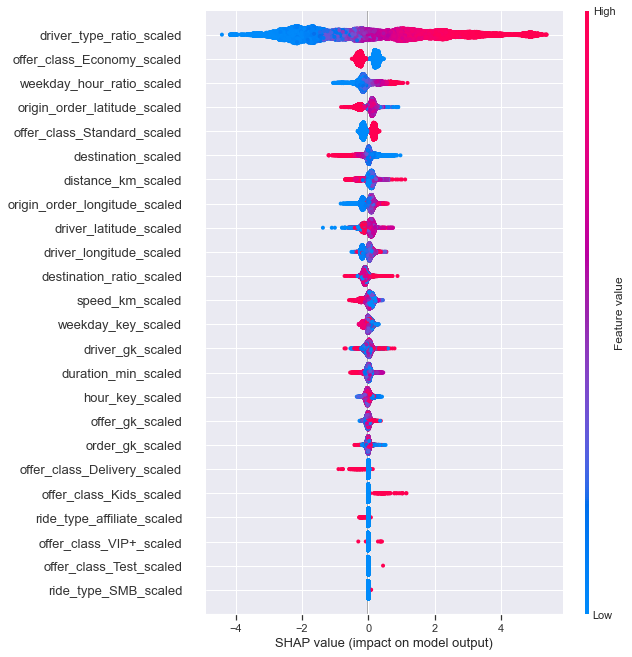

In [64]:
shap.summary_plot(shap_val, X_test_scaled_importance, max_display=25, auto_size_plot=True)

Рассмотрим shap-график и попытаемся его интерпретировать.

Наиболее важным признаком для модели является driver_type_ratio_scaled - доля принятия заказов для конкретного водителя и конкретного типа заказа.


Синие значения соответствуют меньшим значениям этого признака, а красные - наибольшим значениям. Так как синие точки находятся левее оси, это означает, что чем меньшее значение имеет driver_type_ratio_scaled, 
тем больше модель относит объект к классу 0. Красные точки говорят о том, что чем больше значение driver_type_ratio_scaled 
у данного объекта, тем сильнее модель склоняется к тому, чтобы отнести этот объект к классу 1.

### Conclusion

Проведен анализ данных о принятии заказов водителями такси, на основании которого были заменены некоторые пропущенные значения, сгенерированы признаки о дистанции до заказчика, скорости движения, отношения принятых заказов к отклоненным в зависимости
от дня недели и часа, доли принятия заказов для конкретного водителя в зависимости от дня недели / часа / типа поездки / типа заказа. Определена важность признаков при помощи eli5, найдены оптимальные гиперпараметры модели при помощи Optuna. Проведен shap-анализ. В качестве начальной модели применялся LogisticRegression, в качестве окончательной - CatBoostClassifier.
В результате итоговая точность модели составила 0.839.